## BiasMag Figure 1 — Compute ESS + Generate Figure (no overwrite)

This notebook:

- Computes **relative ESS (ESS / N)** for **Yahoo / Coat / KuaiRec** using the same logic as `pranathi3/ess/*.ipynb`.
- Writes a **new** CSV (does **not** overwrite templates): `data/relative_ess_by_dataset.generated.csv`.
- Loads biased metrics from `../biased data/results/metrics_*.txt` and unbiased metrics from `data/unbiased_metrics.csv`.
- Computes bias (Eq. 11) and generates **Figure 1** scatter: `relative_ESS` vs `|Bias_NDCG@10|`.
- Saves a **new** PNG: `figure1_bias_vs_ess.generated.png`.

If a file already exists, the notebook writes a timestamped variant instead.


In [9]:
import os
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

METRIC_COLS = ["RMSE", "MAE", "NDCG@5", "NDCG@10", "Recall@5", "Recall@10"]
KEY_COLS = ["Dataset", "Architecture"]


def find_pranathi3():
    cwd = os.path.abspath(os.getcwd())
    d = cwd
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "bias_magnitude_analysis")) and os.path.isdir(os.path.join(d, "biased data")):
            return d
        sub = os.path.join(d, "pranathi3")
        if os.path.isdir(sub) and os.path.isdir(os.path.join(sub, "bias_magnitude_analysis")) and os.path.isdir(os.path.join(sub, "biased data")):
            return sub
        d = os.path.dirname(d)
    return cwd


PRANATHI3 = find_pranathi3()
ROOT = os.path.join(PRANATHI3, "bias_magnitude_analysis")
DATA_DIR = os.path.join(ROOT, "data")
BIASED_RESULTS_DIR = os.path.join(PRANATHI3, "biased data", "results")

UNBIASED_CSV = os.path.join(DATA_DIR, "unbiased_metrics.csv")
ESS_OUT_DEFAULT = os.path.join(DATA_DIR, "relative_ess_by_dataset.generated.csv")
FIG_OUT_DEFAULT = os.path.join(ROOT, "figure1_bias_vs_ess.generated.png")

print("PRANATHI3 =", PRANATHI3)
print("ROOT     =", ROOT)
print("DATA_DIR =", DATA_DIR)
print("BIASED_RESULTS_DIR =", BIASED_RESULTS_DIR)

PRANATHI3 = c:\Users\prana\OneDrive\Documents\thesis\pranathi3
ROOT     = c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis
DATA_DIR = c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data
BIASED_RESULTS_DIR = c:\Users\prana\OneDrive\Documents\thesis\pranathi3\biased data\results


In [10]:
def safe_out_path(path: str) -> str:
    """If path exists, append timestamp before extension."""
    if not os.path.exists(path):
        return path
    base, ext = os.path.splitext(path)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{base}.{ts}{ext}"


def compute_ess(weights) -> float:
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    return float((w.sum() ** 2) / np.square(w).sum())


def compute_relative_ess(weights) -> float:
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    ess = compute_ess(w)
    return float(ess / w.size)


def compute_rel_ess_from_df(df: pd.DataFrame, item_col: str, min_propensity: float = 1e-4) -> tuple[float, float, int]:
    """Popularity-propensity ESS: propensity(item)=count(item)/N; weight=1/propensity; returns (ESS, relESS, N)."""
    N = len(df)
    counts = df[item_col].value_counts()
    props = (counts / float(N)).to_dict()
    prop = df[item_col].map(lambda i: max(props.get(i, min_propensity), min_propensity)).astype(float)
    w = 1.0 / prop.values
    return compute_ess(w), compute_relative_ess(w), N

In [11]:
# --- Load datasets (same sources as ess/*.ipynb) ---

yahoo_path = os.path.join(PRANATHI3, "data", "yahoo_data", "user.txt")
coat_path = os.path.join(PRANATHI3, "data", "coat_data", "coat_data", "coat", "coat_combined.csv")
kuairec_path = os.path.join(PRANATHI3, "data", "kuairec_data", "kuairec_combined.csv")

print("Yahoo path :", yahoo_path)
print("Coat path  :", coat_path)
print("KuaiRec path:", kuairec_path)

# Yahoo user.txt has no header: userId, itemId, rating
if not os.path.isfile(yahoo_path):
    raise FileNotFoundError(yahoo_path)
yahoo_df = pd.read_csv(yahoo_path, names=["userId", "itemId", "rating"])

# Coat combined: has columns userId, itemId, rating
if not os.path.isfile(coat_path):
    raise FileNotFoundError(coat_path)
coat_df = pd.read_csv(coat_path)

# KuaiRec combined: has columns userId, itemId, rating
if not os.path.isfile(kuairec_path):
    raise FileNotFoundError(kuairec_path)
kuairec_df = pd.read_csv(kuairec_path)

# Compute relative ESS
ess_yahoo, rel_ess_yahoo, N_yahoo = compute_rel_ess_from_df(yahoo_df, "itemId")
ess_coat, rel_ess_coat, N_coat = compute_rel_ess_from_df(coat_df, "itemId")
ess_kuairec, rel_ess_kuairec, N_kuairec = compute_rel_ess_from_df(kuairec_df, "itemId")

print(f"Yahoo  : N={N_yahoo} ESS={ess_yahoo:.2f} relESS={rel_ess_yahoo:.4f}")
print(f"Coat   : N={N_coat} ESS={ess_coat:.2f} relESS={rel_ess_coat:.4f}")
print(f"KuaiRec: N={N_kuairec} ESS={ess_kuairec:.2f} relESS={rel_ess_kuairec:.4f}")

Yahoo path : c:\Users\prana\OneDrive\Documents\thesis\pranathi3\data\yahoo_data\user.txt
Coat path  : c:\Users\prana\OneDrive\Documents\thesis\pranathi3\data\coat_data\coat_data\coat\coat_combined.csv
KuaiRec path: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\data\kuairec_data\kuairec_combined.csv
Yahoo  : N=311704 ESS=134538.86 relESS=0.4316
Coat   : N=11600 ESS=10450.12 relESS=0.9009
KuaiRec: N=12530806 ESS=9836193.75 relESS=0.7850


In [12]:
# --- Write generated relative ESS CSV (no overwrite) ---

out_csv = safe_out_path(ESS_OUT_DEFAULT)

rows = []
for dataset, rel in [
    ("YAHOO", rel_ess_yahoo),
    ("COAT", rel_ess_coat),
    ("KUAIREC", rel_ess_kuairec),
]:
    for arch in ["MF", "NCF", "LightGCN"]:
        rows.append({"Dataset": dataset, "Architecture": arch, "relative_ESS": float(rel)})

df_rel = pd.DataFrame(rows)
df_rel.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
display(df_rel)

Wrote: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\relative_ess_by_dataset.generated.20260318_132107.csv


,Dataset,Architecture,relative_ESS
0,YAHOO,MF,0.431624
1,YAHOO,NCF,0.431624
2,YAHOO,LightGCN,0.431624
3,COAT,MF,0.900872
4,COAT,NCF,0.900872
5,COAT,LightGCN,0.900872
6,KUAIREC,MF,0.784961
7,KUAIREC,NCF,0.784961
8,KUAIREC,LightGCN,0.784961


In [13]:
# --- Load biased metrics from biased data/results/metrics_*.txt (same as Bias_Magnitude_Analysis.ipynb parsing) ---

def parse_metrics_txt(filepath: str) -> dict:
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
    rmse = re.search(r"Test RMSE:\s*([\d.]+)", text)
    mae = re.search(r"Test MAE:\s*([\d.]+)", text)

    name = os.path.basename(filepath).lower()
    if "pranathi" in name and "mf" in name:
        dataset, arch = "YAHOO", "MF"
    elif "pranathi" in name:
        dataset, arch = "YAHOO", "NCF"
    elif "coat" in name:
        dataset, arch = "COAT", "NCF"
    elif "kuairec" in name and "mf" in name:
        dataset, arch = "KUAIREC", "MF"
    elif "kuairec" in name:
        dataset, arch = "KUAIREC", "NCF"
    else:
        dataset, arch = "UNKNOWN", "UNKNOWN"

    return {
        "Dataset": dataset,
        "Architecture": arch,
        "Model": "Naive ERM",
        "RMSE": float(rmse.group(1)) if rmse else np.nan,
        "MAE": float(mae.group(1)) if mae else np.nan,
        "NDCG@5": np.nan,
        "NDCG@10": np.nan,
        "Recall@5": np.nan,
        "Recall@10": np.nan,
        "Split": "biased",
    }


def load_biased_from_txt(results_dir: str) -> pd.DataFrame:
    rows = []
    if not os.path.isdir(results_dir):
        return pd.DataFrame(rows)
    for f in os.listdir(results_dir):
        if f.startswith("metrics_") and f.endswith(".txt"):
            path = os.path.join(results_dir, f)
            rows.append(parse_metrics_txt(path))
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.drop_duplicates(subset=["Dataset", "Architecture"], keep="last")


df_biased = load_biased_from_txt(BIASED_RESULTS_DIR)
print("Biased rows:", len(df_biased))
display(df_biased)

Biased rows: 5


,Dataset,Architecture,Model,RMSE,MAE,NDCG@5,NDCG@10,Recall@5,Recall@10,Split
0,COAT,NCF,Naive ERM,0.2788,0.2233,NaN,NaN,NaN,NaN,biased
1,KUAIREC,NCF,Naive ERM,0.0029,0.0009,NaN,NaN,NaN,NaN,biased
2,KUAIREC,MF,Naive ERM,NaN,NaN,NaN,NaN,NaN,NaN,biased
3,YAHOO,MF,Naive ERM,0.3117,0.2665,NaN,NaN,NaN,NaN,biased
4,YAHOO,NCF,Naive ERM,0.3075,0.2380,NaN,NaN,NaN,NaN,biased


In [14]:
# --- Load unbiased metrics ---

if not os.path.isfile(UNBIASED_CSV):
    raise FileNotFoundError(UNBIASED_CSV)

df_unbiased = pd.read_csv(UNBIASED_CSV)
df_unbiased["Split"] = "unbiased"

# Ensure metric columns exist
for m in METRIC_COLS:
    if m not in df_unbiased.columns:
        df_unbiased[m] = np.nan

print("Unbiased rows:", len(df_unbiased))
display(df_unbiased)

Unbiased rows: 9


,Dataset,Architecture,Model,RMSE,MAE,NDCG@5,NDCG@10,Recall@5,Recall@10,Split
0,YAHOO,MF,Naive ERM,0.371040,0.305537,0.532178,0.665304,0.451734,0.726296,unbiased
1,YAHOO,NCF,Naive ERM,0.383335,0.308804,0.530331,0.663970,0.449703,0.726296,unbiased
2,YAHOO,LightGCN,Naive ERM,0.837972,0.795236,0.447885,0.613808,0.372790,0.726296,unbiased
3,COAT,MF,Naive ERM,2.150730,1.771777,0.725712,0.807856,0.312500,0.625000,unbiased
4,COAT,NCF,Naive ERM,2.190917,1.884304,0.824467,0.879654,0.312500,0.625000,unbiased
5,COAT,LightGCN,Naive ERM,1.748176,1.228917,0.676512,0.767097,0.312500,0.625000,unbiased
6,KUAIREC,MF,Naive ERM,1.805613,0.677738,0.234255,0.261359,0.026475,0.051791,unbiased
7,KUAIREC,NCF,Naive ERM,1.962863,0.943467,0.449157,0.477328,0.034653,0.067649,unbiased
8,KUAIREC,LightGCN,Naive ERM,1.721569,0.641958,0.191602,0.218638,0.024514,0.048640,unbiased


In [15]:
# --- Compute bias magnitude (Eq. 11) using unbiased as base (9 rows) ---

def compute_bias_magnitude(df_b: pd.DataFrame, df_u: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if df_u.empty:
        return pd.DataFrame(), pd.DataFrame()
    df_b = df_b.copy()
    df_u = df_u.copy()

    for c in KEY_COLS:
        if c in df_b.columns and df_b[c].dtype == object:
            df_b[c] = df_b[c].astype(str).str.strip()
        if c in df_u.columns and df_u[c].dtype == object:
            df_u[c] = df_u[c].astype(str).str.strip()

    for m in METRIC_COLS:
        if m not in df_u.columns:
            df_u[m] = np.nan
        if m not in df_b.columns:
            df_b[m] = np.nan

    merged = df_u[KEY_COLS + METRIC_COLS].merge(
        df_b[KEY_COLS + METRIC_COLS],
        on=KEY_COLS,
        how="left",
        suffixes=("_unbiased", "_biased"),
    )

    out = merged[KEY_COLS].copy()
    for m in METRIC_COLS:
        b = merged[f"{m}_biased"]
        u = merged[f"{m}_unbiased"]
        out[f"Bias_{m}"] = b - u
        out[f"|Bias_{m}|"] = np.abs(b - u)

    return out, merged


df_bias, merged = compute_bias_magnitude(df_biased, df_unbiased)
print("Bias rows:", len(df_bias))
display(df_bias)

Bias rows: 9


,Dataset,Architecture,Bias_RMSE,|Bias_RMSE|,Bias_MAE,|Bias_MAE|,Bias_NDCG@5,|Bias_NDCG@5|,Bias_NDCG@10,|Bias_NDCG@10|,Bias_Recall@5,|Bias_Recall@5|,Bias_Recall@10,|Bias_Recall@10|
0,YAHOO,MF,-0.059340,0.059340,-0.039037,0.039037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YAHOO,NCF,-0.075835,0.075835,-0.070804,0.070804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YAHOO,LightGCN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COAT,MF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,COAT,NCF,-1.912117,1.912117,-1.661004,1.661004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,COAT,LightGCN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,KUAIREC,MF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,KUAIREC,NCF,-1.959963,1.959963,-0.942567,0.942567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,KUAIREC,LightGCN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Falling back to |Bias_RMSE| so the plot is not blank.


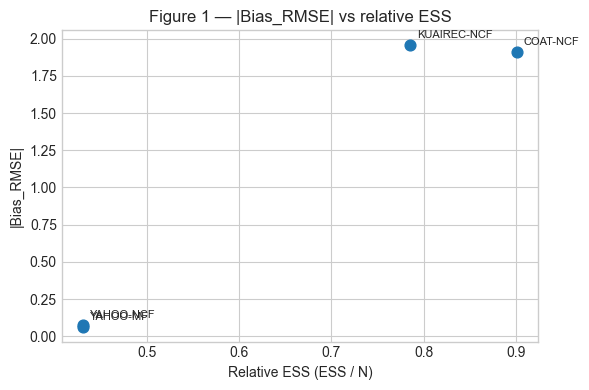

Saved figure: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\figure1_biasRMSE_vs_ess.generated.png
ESS CSV: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\relative_ess_by_dataset.generated.20260318_132107.csv
Saved plot data: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\figure1_plot_data.Bias_RMSE.generated.csv


In [16]:
# --- Generate Figure 1: relative ESS vs bias magnitude ---
# Thesis uses |Bias_NDCG@10|. If biased metrics do not contain NDCG@10, this notebook falls back to |Bias_RMSE|
# so the figure is not blank (and prints a clear warning).

plot_df = df_bias.merge(df_rel, on=["Dataset", "Architecture"], how="inner")
if plot_df.empty:
    raise RuntimeError("No overlap between bias table and relative ESS table")

preferred = "|Bias_NDCG@10|"
fallback = "|Bias_RMSE|"

if preferred in plot_df.columns and not plot_df[preferred].dropna().empty:
    y_col = preferred
    fig_name = "figure1_bias_vs_ess.generated.png"
else:
    print(
        "WARNING: |Bias_NDCG@10| is NaN for all rows (biased metrics don't include NDCG@10).\n"
        "Falling back to |Bias_RMSE| so the plot is not blank."
    )
    if fallback not in plot_df.columns or plot_df[fallback].dropna().empty:
        raise RuntimeError("Fallback |Bias_RMSE| is also missing/NaN. Cannot plot.")
    y_col = fallback
    fig_name = "figure1_biasRMSE_vs_ess.generated.png"

fig_out = safe_out_path(os.path.join(ROOT, fig_name))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(plot_df["relative_ESS"], plot_df[y_col], s=60)
for _, row in plot_df.iterrows():
    ax.annotate(
        f"{row['Dataset']}-{row['Architecture']}",
        (row["relative_ESS"], row[y_col]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_xlabel("Relative ESS (ESS / N)")
ax.set_ylabel(y_col)
ax.set_title(f"Figure 1 — {y_col} vs relative ESS")
plt.tight_layout()
plt.savefig(fig_out, dpi=150)
plt.show()

print("Saved figure:", fig_out)
print("ESS CSV:", out_csv)

# Also write the plotted data (no overwrite)
plot_csv = safe_out_path(os.path.join(DATA_DIR, f"figure1_plot_data.{y_col.replace('|','').replace('@','at').replace(':','')}.generated.csv"))
plot_df[["Dataset", "Architecture", "relative_ESS", y_col]].to_csv(plot_csv, index=False)
print("Saved plot data:", plot_csv)

## (Optional) Generate Figure 1 popularity-quartile bar chart

This reproduces the *popularity quartile* placeholder figure (Q1–Q4) using the **real values** printed in:
`pranathi3/coat_shopping/LightGCN_Notebooks/LightGCN_Coat_Debiased_Methods.ipynb`.

It saves a new PNG and a CSV (no overwrite).

Saved quartile data: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\data\figure1_popularity_quartiles.generated.20260318_133947.csv


,Quartile,Method,NDCG@10
0,Q1 (Rare),Naive,0.3387
1,Q1 (Rare),IPS,0.3392
2,Q1 (Rare),CRM,0.3412
3,Q2,Naive,0.3716
4,Q2,IPS,0.3708
5,Q2,CRM,0.3699
6,Q3,Naive,0.3792
7,Q3,IPS,0.3753
8,Q3,CRM,0.3780
9,Q4 (Popular),Naive,0.4273


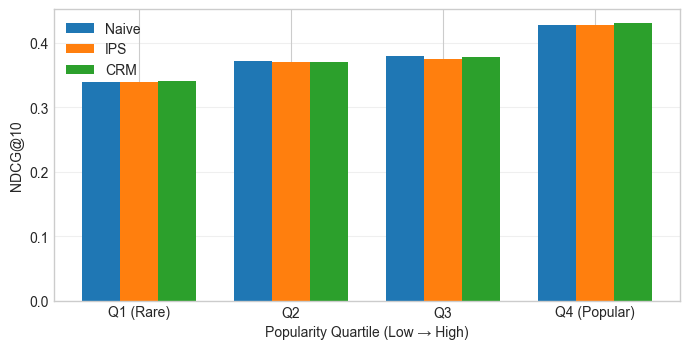

Saved quartile figure: c:\Users\prana\OneDrive\Documents\thesis\pranathi3\bias_magnitude_analysis\figure1_popularity_quartiles.generated.20260318_133947.png


In [18]:
# --- Popularity Quartile Figure (Q1-Q4) from Section 6.5 values ---
# Source: LightGCN_Coat_Debiased_Methods.ipynb printed table.
# NOTE: These values are for COAT (LightGCN debiased notebook run). If you have Yahoo/KuaiRec equivalents,
# paste them here and re-run this cell.

quartiles = ["Q1 (Rare)", "Q2", "Q3", "Q4 (Popular)"]

# Values copied from notebook output:
# Q1(Rare)    Baseline 0.3387   IPS 0.3392   CRM 0.3412
# Q2          Baseline 0.3716   IPS 0.3708   CRM 0.3699
# Q3          Baseline 0.3792   IPS 0.3753   CRM 0.3780
# Q4(Popular) Baseline 0.4273   IPS 0.4271   CRM 0.4309

vals = {
    "Naive": [0.3387, 0.3716, 0.3792, 0.4273],
    "IPS":   [0.3392, 0.3708, 0.3753, 0.4271],
    "CRM":   [0.3412, 0.3699, 0.3780, 0.4309],
}

# Save plotted data (no overwrite)
pop_csv = safe_out_path(os.path.join(DATA_DIR, "figure1_popularity_quartiles.generated.csv"))
rows = []
for i, q in enumerate(quartiles):
    for method in ["Naive", "IPS", "CRM"]:
        rows.append({"Quartile": q, "Method": method, "NDCG@10": float(vals[method][i])})

df_pop = pd.DataFrame(rows)
df_pop.to_csv(pop_csv, index=False)
print("Saved quartile data:", pop_csv)
display(df_pop)

# Plot
pop_png = safe_out_path(os.path.join(ROOT, "figure1_popularity_quartiles.generated.png"))

x = np.arange(len(quartiles))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(x - width, vals["Naive"], width, label="Naive")
ax.bar(x,         vals["IPS"],   width, label="IPS")
ax.bar(x + width, vals["CRM"],   width, label="CRM")

ax.set_xticks(x)
ax.set_xticklabels(quartiles)
ax.set_ylabel("NDCG@10")
ax.set_xlabel("Popularity Quartile (Low → High)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(pop_png, dpi=200)
plt.show()

print("Saved quartile figure:", pop_png)